## 🔧 Step 1: Install Mantis

We begin by installing the `mantis` package directly from GitHub. This will download the latest version of the code and install all required dependencies.

In [1]:
# Clone the full Mantis repository and move into it
!git clone https://github.com/carsondudley1/Mantis.git
%cd Mantis

# Install the package in editable mode
!pip install -e .

Cloning into 'Mantis'...
remote: Enumerating objects: 234, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 234 (delta 38), reused 2 (delta 2), pack-reused 155 (from 1)
Receiving objects: 100% (234/234), 218.61 KiB | 1.87 MiB/s, done.
Resolving deltas: 100% (120/120), done.
/content/Mantis
Obtaining file:///content/Mantis
  Preparing metadata (setup.py) ... done
  Running setup.py develop for mantis


## 📦 Step 2: Download the Pretrained Model

Mantis uses pretrained simulation-grounded foundation models for forecasting.  
In this tutorial, we’ll use the **4-week horizon model with covariates**.

This cell downloads the model file (~1 GB) from the [GitHub release](https://github.com/carsondudley1/Mantis/releases/tag/mantis-v1.0) and places it in a local `models/` directory.

In [2]:
# Download the 4-week model that takes covariates

!mkdir -p models
!wget -O models/mantis_4w_cov.pt https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_4w_cov.pt
!wget -O models/mantis_4w_nocov.pt https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_4w_nocov.pt

--2026-03-26 12:50:16--  https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_4w_cov.pt
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1028419690/2f95c870-6a12-4737-a6f9-a9332d52ae01?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-26T13%3A49%3A41Z&rscd=attachment%3B+filename%3Dmantis_4w_cov.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-26T12%3A49%3A41Z&ske=2026-03-26T13%3A49%3A41Z&sks=b&skv=2018-11-09&sig=9tz4S2Z3dcfmFajHcNTi2VePmrUgUN%2FUSwKNMuL%2FIX0%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDUzMzAxNiwibmJmIjoxNzc0NTI5NDE2LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZ

## 📊 Step 3: Import Mantis and Load Example Data

We now import the `Mantis` model and load example COVID-19 hospitalization data.  
This dataset includes daily hospitalization counts for all 50 U.S. states, Washington DC, and Puerto Rico, with columns labeled by state abbreviation (e.g., `ca`, `ny`, `tx`).

We'll extract the weekly time series for each state and use that as our forecasting input.  

Spatial covariate assignments:
  ak   → (none — excluded)
  al   → fl
  ar   → tx
  az   → ca
  ca   → az
  co   → az
  ct   → ny
  dc   → va
  de   → pa
  fl   → ga
  ga   → fl
  hi   → (none — excluded)
  ia   → il
  id   → wa
  il   → in
  in   → il
  ks   → mo
  ky   → il
  la   → tx
  ma   → ny
  md   → pa
  me   → nh
  mi   → oh
  mn   → wi
  mo   → il
  ms   → tn
  mt   → id
  nc   → ga
  nd   → mn
  ne   → mo
  nh   → ma
  nj   → ny
  nm   → tx
  nv   → ca
  ny   → pa
  oh   → pa
  ok   → tx
  or   → ca
  pa   → ny
  pr   → (none — excluded)
  ri   → ma
  sc   → ga
  sd   → mn
  tn   → ga
  tx   → la
  ut   → az
  va   → nc
  vt   → ny
  wa   → or
  wi   → il
  wv   → pa
  wy   → co

49 states included (excluded: ['ak', 'hi', 'pr'])


States: 100%|██████████| 49/49 [32:13<00:00, 39.45s/it]


No-covariate MAE : 89.78
Spatial MAE      : 85.47
Relative change  : -4.8%



/tmp/ipykernel_374/1051741524.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


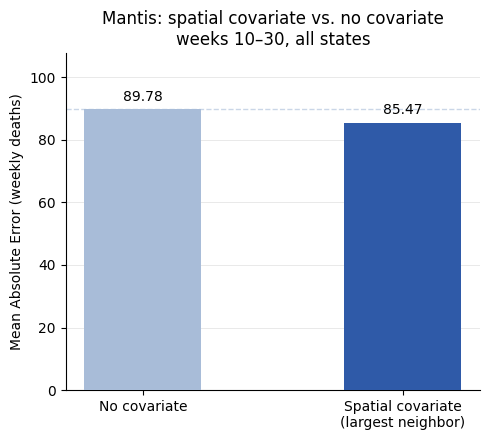

In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────
from mantis import Mantis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Load data ─────────────────────────────────────────────────────────────────
deaths_df = pd.read_csv("data/covid_deaths.csv")
states    = [c for c in deaths_df.columns]

# ── State adjacency (shared border) ──────────────────────────────────────────
ADJACENCY = {
    "al": ["fl","ga","ms","tn"],          "ak": [],
    "az": ["ca","co","nm","nv","ut"],     "ar": ["la","mo","ms","ok","tn","tx"],
    "ca": ["az","nv","or"],               "co": ["az","ks","ne","nm","ok","ut","wy"],
    "ct": ["ma","ny","ri"],               "de": ["md","nj","pa"],
    "fl": ["al","ga"],                    "ga": ["al","fl","nc","sc","tn"],
    "hi": [],
    "id": ["mt","nv","or","ut","wa","wy"],"il": ["ia","in","ky","mo","wi"],
    "in": ["il","ky","mi","oh"],          "ia": ["il","mn","mo","ne","sd","wi"],
    "ks": ["co","mo","ne","ok"],          "ky": ["il","in","mo","oh","tn","va","wv"],
    "la": ["ar","ms","tx"],               "me": ["nh"],
    "md": ["de","pa","va","wv"],          "ma": ["ct","nh","ny","ri","vt"],
    "mi": ["in","oh","wi"],               "mn": ["ia","nd","sd","wi"],
    "ms": ["al","ar","la","tn"],          "mo": ["ar","ia","il","ks","ky","ne","ok","tn"],
    "mt": ["id","nd","sd","wy"],          "ne": ["co","ia","ks","mo","sd","wy"],
    "nv": ["az","ca","id","or","ut"],     "nh": ["ma","me","vt"],
    "nj": ["de","ny","pa"],               "nm": ["az","co","ok","tx"],
    "ny": ["ct","ma","nj","pa","vt"],     "nc": ["ga","sc","tn","va"],
    "nd": ["mn","mt","sd"],               "oh": ["in","ky","mi","pa","wv"],
    "ok": ["ar","co","ks","mo","nm","tx"],"or": ["ca","id","nv","wa"],
    "pa": ["de","md","nj","ny","oh","wv"],"ri": ["ct","ma"],
    "sc": ["ga","nc"],                    "sd": ["ia","mn","mt","nd","ne","wy"],
    "tn": ["al","ar","ga","ky","mo","ms","nc","va"],
    "tx": ["ar","la","nm","ok"],          "ut": ["az","co","id","nv","nm","wy"],
    "vt": ["ma","nh","ny"],               "va": ["ky","md","nc","tn","wv"],
    "wa": ["id","or"],                    "wv": ["ky","md","oh","pa","va"],
    "wi": ["ia","il","mi","mn"],          "wy": ["co","id","mt","ne","sd","ut"],
    "dc": ["md","va"],
}

# US state populations (2020 census, thousands) for picking largest neighbor
STATE_POP = {
    "ca":39538,"tx":29145,"fl":21538,"ny":20201,"pa":13002,"il":12812,
    "oh":11799,"ga":10711,"nc":10439,"mi":10077,"nj":9288,"va":8631,
    "wa":7705,"az":7151,"tn":6910,"ma":7029,"in":6785,"mo":6154,
    "md":6177,"wi":5893,"co":5773,"mn":5706,"sc":5118,"al":5024,
    "la":4657,"ky":4505,"or":4237,"ok":3959,"ct":3605,"ut":3271,
    "ia":3190,"nv":3104,"ar":3011,"ms":2961,"ks":2937,"nm":2117,
    "ne":1961,"id":1839,"wv":1793,"hi":1455,"nh":1377,"me":1362,
    "mt":1084,"ri":1097,"de":989,"sd":886,"nd":779,"ak":733,
    "vt":643,"wy":576,"dc":689,
}

# ── Build spatial covariate map: state → largest-population adjacent state ───
def largest_neighbor(state, available_states):
    neighbors = [s for s in ADJACENCY.get(state, []) if s in available_states]
    if not neighbors:
        return None
    return max(neighbors, key=lambda s: STATE_POP.get(s, 0))

available = set(states)
spatial_covariate = {s: largest_neighbor(s, available) for s in states}

print("Spatial covariate assignments:")
for s, cov in sorted(spatial_covariate.items()):
    print(f"  {s:4s} → {cov if cov else '(none — excluded)'}")

# ── Models ────────────────────────────────────────────────────────────────────
model_spatial   = Mantis(forecast_horizon=4, use_covariate=True)
model_no_cov    = Mantis(forecast_horizon=4, use_covariate=False)

BURN_IN  = 10
HORIZON  = 4

min_len = min(len(deaths_df[s]) for s in states)
MAX_WEEK = min_len - HORIZON

week_indices = range(BURN_IN, MAX_WEEK)

# Exclude states with no valid neighbor
states_eval = [s for s in states if spatial_covariate[s] is not None]
print(f"\n{len(states_eval)} states included (excluded: "
      f"{[s for s in states if spatial_covariate[s] is None]})")

# mae_spatial / mae_nocov: list of per-(state, week) MAEs
mae_spatial = []
mae_nocov   = []

for state in tqdm(states_eval, desc="States"):
    deaths_ts = deaths_df[state].values
    cov_state = spatial_covariate[state]
    cov_ts    = deaths_df[cov_state].values

    for week in week_indices:
        if week + HORIZON > len(deaths_ts):
            continue
        true_future = deaths_ts[week : week + HORIZON]
        if np.any(np.isnan(true_future)):
            continue

        # ── No-covariate model ───────────────────────────────────────────────
        try:
            pred_nc  = model_no_cov.predict(time_series=deaths_ts[:week])
            median_nc = pred_nc[:, 4]
            mae_nocov.append(np.mean(np.abs(median_nc - true_future)))
        except Exception:
            continue                        # skip week if either model fails

        # ── Spatial-covariate model ──────────────────────────────────────────
        try:
            pred_sp   = model_spatial.predict(
                time_series    = deaths_ts[:week],
                covariate      = cov_ts[:week],
                target_type    = 2,
                covariate_type = 1,         # neighbor deaths, same type
            )
            median_sp = pred_sp[:, 4]
            mae_spatial.append(np.mean(np.abs(median_sp - true_future)))
        except Exception:
            mae_spatial.pop()               # keep lists in sync
            continue

# ── Aggregate ─────────────────────────────────────────────────────────────────
mean_nocov   = np.mean(mae_nocov)
mean_spatial = np.mean(mae_spatial)

print(f"\nNo-covariate MAE : {mean_nocov:.2f}")
print(f"Spatial MAE      : {mean_spatial:.2f}")
print(f"Relative change  : {(mean_spatial - mean_nocov) / mean_nocov * 100:+.1f}%")

Saved → mantis_spatial_vs_nocov_mae.pdf


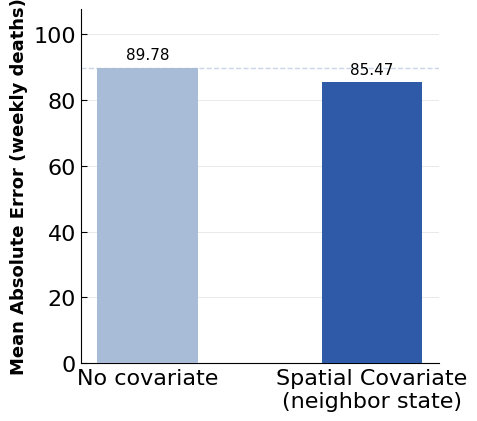

States included       : 49
No-covariate MAE      : 89.78
Spatial MAE           : 85.47
Relative improvement  : +4.8%


In [7]:
# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        16,
    "axes.labelsize":   13,
    "axes.labelweight": "bold",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "xtick.direction":  "in",
    "ytick.direction":  "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

fig, ax = plt.subplots(figsize=(5, 4.5))

labels = ["No covariate", "Spatial Covariate\n(neighbor state)"]
values = [mean_nocov, mean_spatial]
colors = ["#a8bcd8", "#2f5aa8"]

bars = ax.bar(labels, values, color=colors, width=0.45, zorder=3)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11)

ax.axhline(mean_nocov, color="#a8bcd8", linewidth=1.0, linestyle="--", alpha=0.6)
ax.set_ylabel("Mean Absolute Error (weekly deaths)")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linewidth=0.5, alpha=0.4, zorder=0)

fig.tight_layout()

out_path = "mantis_spatial_vs_nocov_mae.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved → {out_path}")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"States included       : {len(states_eval)}")
print(f"No-covariate MAE      : {mean_nocov:.2f}")
print(f"Spatial MAE           : {mean_spatial:.2f}")
print(f"Relative improvement  : {(mean_nocov - mean_spatial) / mean_nocov * 100:+.1f}%")